# Consistency Analysis Across Runs

Analyze prediction agreement across 3 runs for each condition using:
- **Consistency Rate**: Proportion of cases with identical predictions across all runs
- **Fleiss' Kappa**: Inter-rater agreement statistic for multiple raters

In [1]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

---
## 1. Core Functions

In [2]:
def load_results(base_path, condition, runs=[1, 2, 3]):
    """Load results for a condition across multiple runs."""
    results = {}
    for run in runs:
        fpath = Path(base_path) / f"{condition}_run{run}" / "results.jsonl"
        if fpath.exists():
            with open(fpath) as f:
                entries = [json.loads(l) for l in f]
            results[f"run{run}"] = {e.get("case_idx", e.get("idx")): e for e in entries}
    return results


def compute_fleiss_kappa(results):
    """
    Compute Fleiss' kappa for inter-run agreement on PREDICTIONS.
    
    Each case = subject, each run = rater, prediction label = category.
    """
    runs = list(results.keys())
    n_raters = len(runs)
    
    if n_raters < 2:
        return None
    
    # Collect predictions for each case
    all_cases = set()
    for run_data in results.values():
        all_cases.update(run_data.keys())
    
    categories = set()
    case_predictions = {}
    
    for case_idx in sorted(all_cases):
        preds = []
        for run in runs:
            if case_idx in results[run]:
                pred = results[run][case_idx].get("prediction")
                if pred is not None:
                    preds.append(pred)
                    categories.add(pred)
        if len(preds) == n_raters:
            case_predictions[case_idx] = preds
    
    if not case_predictions:
        return None
    
    categories = sorted(categories)
    n_subjects = len(case_predictions)
    
    P_i_values = []
    category_totals = {cat: 0 for cat in categories}
    
    for case_idx, preds in case_predictions.items():
        counts = {cat: preds.count(cat) for cat in categories}
        for pred in preds:
            category_totals[pred] += 1
        
        # P_i = (1 / (n*(n-1))) * sum(n_ij * (n_ij - 1))
        sum_nij_squared = sum(c * (c - 1) for c in counts.values())
        P_i = sum_nij_squared / (n_raters * (n_raters - 1))
        P_i_values.append(P_i)
    
    P_bar = np.mean(P_i_values)
    total_ratings = n_subjects * n_raters
    P_e = sum((category_totals[cat] / total_ratings) ** 2 for cat in categories)
    
    if P_e == 1:
        return 1.0
    return (P_bar - P_e) / (1 - P_e)


def compute_prediction_consistency(results):
    """
    Compute consistency rate = proportion with same prediction across all runs.
    Returns: (consistent_count, total_count, consistency_rate)
    """
    runs = list(results.keys())
    all_cases = set()
    for run_data in results.values():
        all_cases.update(run_data.keys())
    
    consistent = total = 0
    for case_idx in sorted(all_cases):
        preds = []
        for run in runs:
            if case_idx in results[run]:
                pred = results[run][case_idx].get("prediction")
                if pred is not None:
                    preds.append(pred)
        if len(preds) == len(runs):
            total += 1
            if len(set(preds)) == 1:
                consistent += 1
    
    rate = consistent / total * 100 if total > 0 else 0
    return consistent, total, rate

---
## 2. Load All Results

In [3]:
CONDITIONS = ["baseline", "bidir_true", "bidir_false", "spooky_true", "spooky_false", "twostage"]
DATASETS = ["folio", "multilogieval"]
MODELS = ["deepseek", "gpt-5"]

def load_all_results():
    """Load results for all conditions."""
    all_results = {}

    for dataset in DATASETS:
        for model in MODELS:
            for condition in CONDITIONS:
                key = f"{dataset}/{model}/{condition}"

                if condition == "twostage":
                    model_name = "deepseek-r1" if model == "deepseek" else "gpt-5"
                    results = {}
                    for run in [1, 2, 3]:
                        fpath = Path(f"../results/{dataset}/twostage/{model_name}_run{run}/results.jsonl")
                        if fpath.exists():
                            with open(fpath) as f:
                                entries = [json.loads(l) for l in f]
                            results[f"run{run}"] = {e.get("case_idx"): e for e in entries}
                    if results:
                        all_results[key] = results
                else:
                    base_path = f"../results/{dataset}/{model}"
                    results = load_results(base_path, condition)
                    if results:
                        all_results[key] = results

    return all_results

all_results = load_all_results()
print(f"Loaded {len(all_results)} conditions")

Loaded 24 conditions


---
## 3. Compute Consistency Metrics

In [4]:
# Compute metrics for all conditions
metrics_data = []

for key, results in all_results.items():
    parts = key.split("/")
    dataset, model, condition = parts[0], parts[1], parts[2]
    
    kappa = compute_fleiss_kappa(results)
    consistent, total, rate = compute_prediction_consistency(results)
    
    if kappa is not None:
        metrics_data.append({
            "Dataset": dataset,
            "Model": model,
            "Condition": condition,
            "Consistent": consistent,
            "Inconsistent": total - consistent,
            "Total": total,
            "Consistency %": rate,
            "Fleiss Kappa": kappa
        })

df_metrics = pd.DataFrame(metrics_data)

print("PREDICTION-BASED CONSISTENCY AND FLEISS' KAPPA")
print("=" * 85)
print(df_metrics.to_string(index=False))

PREDICTION-BASED CONSISTENCY AND FLEISS' KAPPA
      Dataset    Model    Condition  Consistent  Inconsistent  Total  Consistency %  Fleiss Kappa
        folio deepseek     baseline         187            16    203      92.118227      0.919004
        folio deepseek   bidir_true         192            11    203      94.581281      0.920405
        folio deepseek  bidir_false         191            12    203      94.088670      0.899863
        folio deepseek  spooky_true         190            13    203      93.596059      0.907119
        folio deepseek spooky_false         190            13    203      93.596059      0.897142
        folio deepseek     twostage         136            63    199      68.341709      0.676099
        folio    gpt-5     baseline         190            13    203      93.596059      0.934104
        folio    gpt-5   bidir_true         198             5    203      97.536946      0.963577
        folio    gpt-5  bidir_false         194             9    203   

In [5]:
# Pivot table view
df_pivot = df_metrics.pivot_table(
    index=["Dataset", "Model"],
    columns="Condition",
    values=["Consistency %", "Fleiss Kappa"],
    aggfunc="first"
)

print("\nCONSISTENCY RATE (%) BY CONDITION")
print(df_pivot["Consistency %"].round(1))

print("\nFLEISS' KAPPA BY CONDITION")
print(df_pivot["Fleiss Kappa"].round(2))


CONSISTENCY RATE (%) BY CONDITION
Condition               baseline  bidir_false  bidir_true  spooky_false  \
Dataset       Model                                                       
folio         deepseek      92.1         94.1        94.6          93.6   
              gpt-5         93.6         95.6        97.5          94.1   
multilogieval deepseek      83.0         87.0        80.0          79.0   
              gpt-5         82.0         92.0        88.0          90.0   

Condition               spooky_true  twostage  
Dataset       Model                            
folio         deepseek         93.6      68.3  
              gpt-5            96.6      71.9  
multilogieval deepseek         85.0      64.6  
              gpt-5            96.0      61.0  

FLEISS' KAPPA BY CONDITION
Condition               baseline  bidir_false  bidir_true  spooky_false  \
Dataset       Model                                                       
folio         deepseek      0.92         0.90   

---
## 4. LaTeX Table for Paper

In [6]:
CONDITION_ORDER = ["baseline", "bidir_true", "bidir_false", "spooky_true", "spooky_false", "twostage"]
CONDITION_LABELS = {
    "baseline": "Baseline",
    "bidir_true": r"Directed$_\text{T}$",
    "bidir_false": r"Directed$_\text{F}$",
    "spooky_true": r"Nudged$_\text{T}$",
    "spooky_false": r"Nudged$_\text{F}$",
    "twostage": "Two-Stage"
}

print(r"""\begin{table}[h]
\centering
\small
\begin{tabular}{llcc}
\toprule
\textbf{Model} & \textbf{Condition} & \textbf{Consistency \%} & \textbf{Fleiss' $\kappa$} \\
\midrule
\multicolumn{4}{l}{\textit{FOLIO (n=203)}} \\
\midrule""")

for dataset in ["folio", "multilogieval"]:
    if dataset == "multilogieval":
        print(r"""\midrule
\multicolumn{4}{l}{\textit{Multi-LogiEval (n=100)}} \\
\midrule""")
    
    for model, model_label in [("gpt-5", "GPT-5"), ("deepseek", "DeepSeek-R1")]:
        print(f"\\multirow{{6}}{{*}}{{{model_label}}}")
        
        for cond in CONDITION_ORDER:
            row = df_metrics[(df_metrics["Dataset"] == dataset) & 
                            (df_metrics["Model"] == model) & 
                            (df_metrics["Condition"] == cond)]
            
            if len(row) > 0:
                consist = row["Consistency %"].values[0]
                kappa = row["Fleiss Kappa"].values[0]
                print(f"  & {CONDITION_LABELS[cond]} & {consist:.1f} & {kappa:.2f} \\\\")
        
        if not (dataset == "multilogieval" and model == "deepseek"):
            print("\\midrule")

print(r"""\bottomrule
\end{tabular}
\caption{Consistency across three runs. Fleiss' $\kappa$ interpretation: 0.81--1.00 (almost perfect), 0.61--0.80 (substantial), 0.41--0.60 (moderate)~\citep{landis1977measurement}.}
\label{tab:consistency}
\end{table}""")

\begin{table}[h]
\centering
\small
\begin{tabular}{llcc}
\toprule
\textbf{Model} & \textbf{Condition} & \textbf{Consistency \%} & \textbf{Fleiss' $\kappa$} \\
\midrule
\multicolumn{4}{l}{\textit{FOLIO (n=203)}} \\
\midrule
\multirow{6}{*}{GPT-5}
  & Baseline & 93.6 & 0.93 \\
  & Directed$_\text{T}$ & 97.5 & 0.96 \\
  & Directed$_\text{F}$ & 95.6 & 0.93 \\
  & Nudged$_\text{T}$ & 96.6 & 0.95 \\
  & Nudged$_\text{F}$ & 94.1 & 0.91 \\
  & Two-Stage & 71.9 & 0.71 \\
\midrule
\multirow{6}{*}{DeepSeek-R1}
  & Baseline & 92.1 & 0.92 \\
  & Directed$_\text{T}$ & 94.6 & 0.92 \\
  & Directed$_\text{F}$ & 94.1 & 0.90 \\
  & Nudged$_\text{T}$ & 93.6 & 0.91 \\
  & Nudged$_\text{F}$ & 93.6 & 0.90 \\
  & Two-Stage & 68.3 & 0.68 \\
\midrule
\midrule
\multicolumn{4}{l}{\textit{Multi-LogiEval (n=100)}} \\
\midrule
\multirow{6}{*}{GPT-5}
  & Baseline & 82.0 & 0.81 \\
  & Directed$_\text{T}$ & 88.0 & 0.84 \\
  & Directed$_\text{F}$ & 92.0 & 0.85 \\
  & Nudged$_\text{T}$ & 96.0 & 0.94 \\
  & Nudged$_\text{

In [7]:
# Summary statistics for paper text
unified_kappas_folio = df_metrics[(df_metrics["Dataset"] == "folio") & 
                                   (df_metrics["Condition"] != "twostage")]["Fleiss Kappa"].values
unified_kappas_multi = df_metrics[(df_metrics["Dataset"] == "multilogieval") & 
                                   (df_metrics["Condition"] != "twostage")]["Fleiss Kappa"].values
twostage_kappas = df_metrics[df_metrics["Condition"] == "twostage"]["Fleiss Kappa"].values

print("SUMMARY FOR PAPER TEXT")
print("=" * 50)
print(f"Unified FOLIO mean kappa: {np.mean(unified_kappas_folio):.2f}")
print(f"Unified Multi-LogiEval mean kappa: {np.mean(unified_kappas_multi):.2f}")
print(f"Two-Stage kappa range: {min(twostage_kappas):.2f} - {max(twostage_kappas):.2f}")

SUMMARY FOR PAPER TEXT
Unified FOLIO mean kappa: 0.92
Unified Multi-LogiEval mean kappa: 0.80
Two-Stage kappa range: 0.56 - 0.71


---
## 5. Visualization

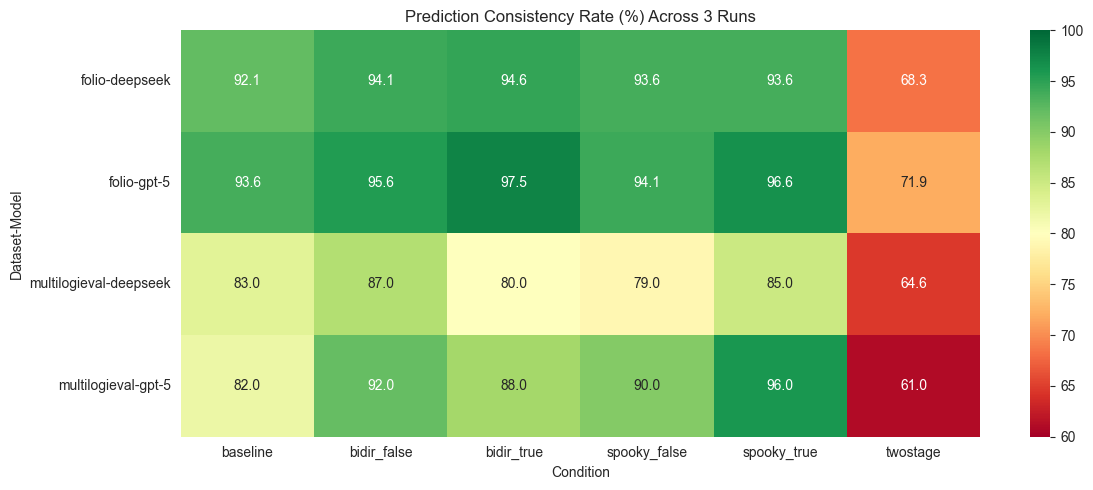

In [8]:
# Heatmap of consistency rates
pivot_numeric = df_metrics.pivot_table(
    index=["Dataset", "Model"],
    columns="Condition",
    values="Consistency %",
    aggfunc="first"
)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot_numeric, annot=True, fmt=".1f", cmap="RdYlGn", 
            vmin=60, vmax=100, center=80)
plt.title("Prediction Consistency Rate (%) Across 3 Runs")
plt.tight_layout()
plt.show()

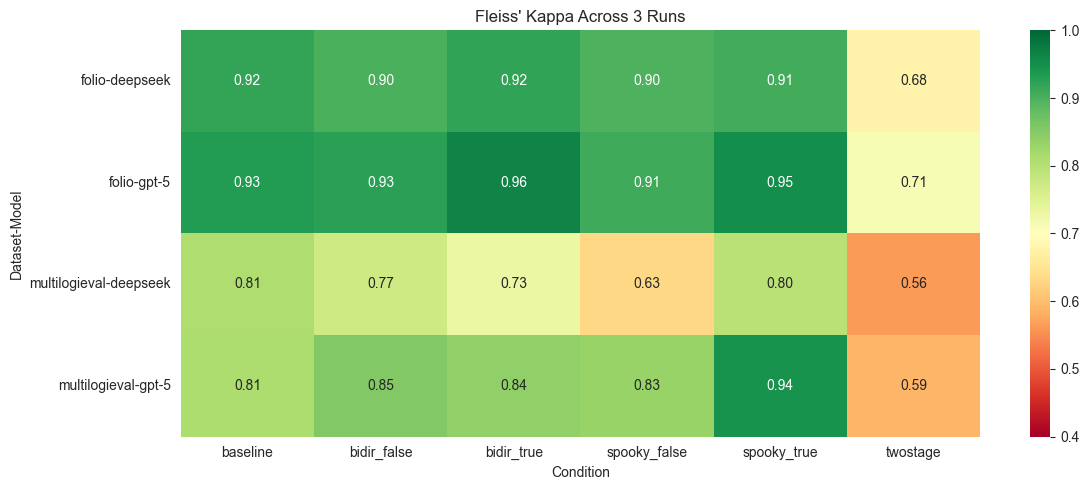

In [9]:
# Fleiss' Kappa heatmap
pivot_kappa = df_metrics.pivot_table(
    index=["Dataset", "Model"],
    columns="Condition",
    values="Fleiss Kappa",
    aggfunc="first"
)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot_kappa, annot=True, fmt=".2f", cmap="RdYlGn", 
            vmin=0.4, vmax=1.0, center=0.7)
plt.title("Fleiss' Kappa Across 3 Runs")
plt.tight_layout()
plt.show()

---
## 6. Two-Stage: Stage-Level Consistency

In [10]:
def compute_field_consistency(results, field):
    """Compute consistency for a boolean field across runs."""
    runs = list(results.keys())
    all_cases = set()
    for run_data in results.values():
        all_cases.update(run_data.keys())
    
    all_true = all_false = inconsistent = 0
    for case_idx in all_cases:
        values = []
        for run in runs:
            if case_idx in results[run]:
                values.append(bool(results[run][case_idx].get(field, False)))
        if len(values) == 3:
            if all(values): 
                all_true += 1
            elif not any(values): 
                all_false += 1
            else: 
                inconsistent += 1
    
    total = all_true + all_false + inconsistent
    return all_true, all_false, inconsistent, total


print("TWO-STAGE CONSISTENCY BY STAGE")
print("=" * 80)

twostage_stage_data = []

for dataset in DATASETS:
    for model_name in ["gpt-5", "deepseek-r1"]:
        results = {}
        for run in [1, 2, 3]:
            fpath = Path(f"../results/{dataset}/twostage/{model_name}_run{run}/results.jsonl")
            if fpath.exists():
                with open(fpath) as f:
                    entries = [json.loads(l) for l in f]
                results[f"run{run}"] = {e.get("case_idx"): e for e in entries}
        
        if len(results) == 3:
            print(f"\n{dataset.upper()} / {model_name.upper()}")
            print("-" * 60)
            
            for field, label in [("correct", "Prediction (Accuracy)"), 
                                  ("stage1_success", "Stage 1 (Translation)"),
                                  ("stage2_success", "Stage 2 (Proving)")]:
                t, f, inc, total = compute_field_consistency(results, field)
                consist = (t + f) / total * 100 if total > 0 else 0
                print(f"  {label:<25} Pass:{t:>3}  Fail:{f:>3}  Incons:{inc:>3}  Consist:{consist:.1f}%")
                
                twostage_stage_data.append({
                    "Dataset": dataset,
                    "Model": model_name,
                    "Stage": label,
                    "All Pass": t,
                    "All Fail": f,
                    "Inconsistent": inc,
                    "Consistency %": consist
                })

df_twostage_stages = pd.DataFrame(twostage_stage_data)

TWO-STAGE CONSISTENCY BY STAGE

FOLIO / GPT-5
------------------------------------------------------------
  Prediction (Accuracy)     Pass:124  Fail: 31  Incons: 48  Consist:76.4%
  Stage 1 (Translation)     Pass:203  Fail:  0  Incons:  0  Consist:100.0%
  Stage 2 (Proving)         Pass:137  Fail: 13  Incons: 53  Consist:73.9%

FOLIO / DEEPSEEK-R1
------------------------------------------------------------
  Prediction (Accuracy)     Pass:119  Fail: 22  Incons: 62  Consist:69.5%
  Stage 1 (Translation)     Pass:199  Fail:  0  Incons:  4  Consist:98.0%
  Stage 2 (Proving)         Pass:146  Fail:  5  Incons: 52  Consist:74.4%

MULTILOGIEVAL / GPT-5
------------------------------------------------------------
  Prediction (Accuracy)     Pass: 39  Fail: 27  Incons: 34  Consist:66.0%
  Stage 1 (Translation)     Pass:100  Fail:  0  Incons:  0  Consist:100.0%
  Stage 2 (Proving)         Pass: 77  Fail:  1  Incons: 22  Consist:78.0%

MULTILOGIEVAL / DEEPSEEK-R1
------------------------------

---
## 7. Two-Stage Inconsistency Root Cause Analysis

Why does GPT-5 Two-Stage on Multi-LogiEval have only 61% consistency (κ=0.59)?

In [11]:
# Analyze GPT-5 Two-Stage inconsistency on Multi-LogiEval
def load_twostage_runs(dataset, model_name):
    """Load all 3 runs for two-stage experiment."""
    runs = {}
    for r in [1, 2, 3]:
        fpath = Path(f"../results/{dataset}/twostage/{model_name}_run{r}/results.jsonl")
        if fpath.exists():
            with open(fpath) as f:
                runs[r] = {json.loads(l)['case_idx']: json.loads(l) for l in f}
    return runs

# Focus on GPT-5 Multi-LogiEval (worst consistency)
runs = load_twostage_runs("multilogieval", "gpt-5")

# Find inconsistent cases
inconsistent = []
for case_idx in runs[1].keys():
    preds = [runs[r][case_idx].get('prediction') for r in [1, 2, 3]]
    s2 = [runs[r][case_idx].get('stage2_success') for r in [1, 2, 3]]
    if len(set(preds)) > 1:
        inconsistent.append({
            'case_idx': case_idx,
            'preds': preds,
            'gt': runs[1][case_idx].get('ground_truth'),
            's2_success': s2
        })

print(f"GPT-5 TWO-STAGE ON MULTI-LOGIEVAL: INCONSISTENCY ANALYSIS")
print("=" * 70)
print(f"Inconsistent cases: {len(inconsistent)}/100 ({len(inconsistent)}%)")
print()

# How many have all S2 pass but still inconsistent?
all_s2_pass = [c for c in inconsistent if all(c['s2_success'])]
print(f"Inconsistent even when ALL Stage 2 passes: {len(all_s2_pass)}/{len(inconsistent)}")
print("  → Problem is in Stage 1 formalization, not Stage 2 proving")
print()

# Check quantifier variation
from collections import Counter
print("PREDICTION PATTERNS (top 10):")
patterns = Counter([tuple(c['preds']) for c in inconsistent])
for pattern, count in patterns.most_common(10):
    print(f"  {pattern}: {count}")

GPT-5 TWO-STAGE ON MULTI-LOGIEVAL: INCONSISTENCY ANALYSIS
Inconsistent cases: 39/100 (39%)

Inconsistent even when ALL Stage 2 passes: 26/39
  → Problem is in Stage 1 formalization, not Stage 2 proving

PREDICTION PATTERNS (top 10):
  ('Yes', 'Uncertain', 'Yes'): 6
  ('Yes', 'Uncertain', 'Uncertain'): 4
  ('Uncertain', 'Uncertain', 'Yes'): 4
  ('No', 'No', 'Uncertain'): 4
  ('No', 'Uncertain', 'No'): 3
  ('Uncertain', 'No', 'Uncertain'): 3
  ('Uncertain', 'No', 'No'): 3
  ('Uncertain', 'Yes', 'Uncertain'): 2
  ('Uncertain', 'Yes', 'Yes'): 2
  ('Yes', 'Yes', 'Uncertain'): 2


In [12]:
# Check for quantifier variation (∃ vs ∀) in Stage 1 formalization
print("QUANTIFIER VARIATION IN INCONSISTENT CASES")
print("=" * 70)
print("(∃=existential, ∀=universal - different choices lead to different provability)")
print()

quantifier_issues = 0
for case in inconsistent[:15]:
    case_idx = case['case_idx']
    codes = [runs[r][case_idx].get('stage1_code', '') for r in [1, 2, 3]]
    
    exists_counts = [c.count('∃') for c in codes]
    forall_counts = [c.count('∀') for c in codes]
    
    if len(set(exists_counts)) > 1 or len(set(forall_counts)) > 1:
        quantifier_issues += 1
        print(f"Case {case_idx}: ∃={exists_counts}, ∀={forall_counts}, Preds={case['preds']}")

print(f"\n{quantifier_issues}/15 sampled cases have quantifier variation in Stage 1")

QUANTIFIER VARIATION IN INCONSISTENT CASES
(∃=existential, ∀=universal - different choices lead to different provability)

Case 14: ∃=[2, 1, 2], ∀=[3, 4, 3], Preds=['Uncertain', 'Yes', 'Uncertain']
Case 87: ∃=[0, 1, 1], ∀=[4, 4, 4], Preds=['Yes', 'Uncertain', 'Uncertain']
Case 85: ∃=[0, 2, 1], ∀=[5, 5, 6], Preds=['Uncertain', 'Uncertain', 'Yes']
Case 16: ∃=[1, 1, 1], ∀=[3, 3, 4], Preds=['Uncertain', 'No', 'Yes']
Case 95: ∃=[0, 1, 1], ∀=[1, 1, 1], Preds=['Yes', 'Uncertain', 'Uncertain']
Case 26: ∃=[0, 1, 0], ∀=[2, 2, 2], Preds=['No', 'No', 'Uncertain']
Case 27: ∃=[0, 0, 0], ∀=[2, 2, 1], Preds=['Uncertain', 'Uncertain', 'No']
Case 30: ∃=[0, 0, 0], ∀=[5, 4, 5], Preds=['No', 'No', 'Uncertain']
Case 35: ∃=[0, 0, 0], ∀=[2, 3, 2], Preds=['Uncertain', 'No', 'Uncertain']

9/15 sampled cases have quantifier variation in Stage 1


### Case Study: Case 14 - NL→FOL Translation Ambiguity

In [13]:
# Case 14: Detailed Stage 1 Formalization Comparison
case_idx = 14

print("CASE 14: STAGE 1 FORMALIZATION ACROSS RUNS")
print("=" * 80)

for r in [1, 2, 3]:
    entry = runs[r][case_idx]
    s1_code = entry.get('stage1_code', '')
    
    print(f"\n{'─'*80}")
    print(f"RUN {r} → Prediction: {entry.get('prediction')}")
    print(f"{'─'*80}")
    
    # Extract key axioms (P4 is the critical one)
    for line in s1_code.split('\n'):
        line = line.strip()
        if line.startswith('axiom P') or line.startswith('axiom H') or line.startswith('axiom Alex'):
            print(f"  {line}")
        if 'theorem goal' in line:
            print(f"  {line}")
    
print("\n" + "=" * 80)
print("KEY DIFFERENCE:")
print("  Run 1 & 3: P4 uses ∃ (existential) - 'someone' does X, not necessarily Alex")
print("  Run 2:     P4 uses ∀ (universal)   - 'everyone' does X, including Alex")
print("=" * 80)
print("Same English premise translated differently → different provability → different answer")

CASE 14: STAGE 1 FORMALIZATION ACROSS RUNS

────────────────────────────────────────────────────────────────────────────────
RUN 1 → Prediction: Uncertain
────────────────────────────────────────────────────────────────────────────────
  axiom Alex : obj
  axiom HopesToExpand : obj → Prop
  axiom P1 : ∃ x : obj, HopesToExpand x
  axiom P2 : ∀ x : obj, AdvertisesCleverly x → AttractMoreCustomers x
  axiom P3 : ∀ x : obj, OffersDiscounts x → IncreaseSales x
  axiom P4 : ∃ x : obj, AdvertisesCleverly x ∨ OffersDiscounts x
  axiom P5 : ∀ x : obj, IncreaseSales x → ExpandBusiness x
  theorem goal : (¬ AttractMoreCustomers Alex) → ExpandBusiness Alex := sorry

────────────────────────────────────────────────────────────────────────────────
RUN 2 → Prediction: Yes
────────────────────────────────────────────────────────────────────────────────
  axiom Alex : obj
  axiom HopesToExpand : obj → Prop
  axiom P1 : ∃ x : obj, HopesToExpand x
  axiom P2 : ∀ x : obj, AdvertisesCleverly x → AttractsMo

In [14]:
# Show full Stage 1 code for Case 14
print("FULL STAGE 1 CODE FOR CASE 14")
print()

for r in [1, 2, 3]:
    entry = runs[r][case_idx]
    print(f"{'='*80}")
    print(f"RUN {r} - Prediction: {entry.get('prediction')}, S2 Success: {entry.get('stage2_success')}")
    print(f"{'='*80}")
    print(entry.get('stage1_code', 'N/A'))
    print()

FULL STAGE 1 CODE FOR CASE 14

RUN 1 - Prediction: Uncertain, S2 Success: True
axiom obj : Type

-- Individuals
axiom Alex : obj

-- Predicates
axiom HopesToExpand : obj → Prop
axiom AdvertisesCleverly : obj → Prop
axiom OffersDiscounts : obj → Prop
axiom AttractMoreCustomers : obj → Prop
axiom IncreaseSales : obj → Prop
axiom ExpandBusiness : obj → Prop

-- Premises
axiom P1 : ∃ x : obj, HopesToExpand x
axiom P2 : ∀ x : obj, AdvertisesCleverly x → AttractMoreCustomers x
axiom P3 : ∀ x : obj, OffersDiscounts x → IncreaseSales x
axiom P4 : ∃ x : obj, AdvertisesCleverly x ∨ OffersDiscounts x
axiom P5 : ∀ x : obj, IncreaseSales x → ExpandBusiness x

-- Conclusion to formalize
theorem goal : (¬ AttractMoreCustomers Alex) → ExpandBusiness Alex := sorry

RUN 2 - Prediction: Yes, S2 Success: True
axiom obj : Type
axiom Alex : obj

axiom HopesToExpand : obj → Prop
axiom AdvertisesCleverly : obj → Prop
axiom OffersDiscounts : obj → Prop
axiom AttractsMoreCustomers : obj → Prop
axiom IncreasesSa

In [15]:
# Show Stage 2 proofs for Case 14
print("STAGE 2 PROOFS FOR CASE 14")
print()

for r in [1, 2, 3]:
    entry = runs[r][case_idx]
    s2_code = entry.get('stage2_code', '')
    
    print(f"{'='*80}")
    print(f"RUN {r} - Prediction: {entry.get('prediction')}")
    print(f"{'='*80}")
    
    # Show just the theorem line with proof
    for line in s2_code.split('\n'):
        if 'theorem goal' in line.lower():
            print(line)
    print()

STAGE 2 PROOFS FOR CASE 14

RUN 1 - Prediction: Uncertain
theorem goal : (¬ AttractMoreCustomers Alex) → ExpandBusiness Alex := by

RUN 2 - Prediction: Yes
theorem goal : ExpandsBusiness Alex := by

RUN 3 - Prediction: Uncertain
theorem goal : ExpandsBusiness Alex := extra_assumption



### Summary: Two-Stage Inconsistency Root Cause

**Key Finding**: The Two-Stage pipeline's low consistency (61% for GPT-5 on Multi-LogiEval) is caused by **non-deterministic NL→FOL translation in Stage 1**, not Stage 2 proof failures.

| Metric | Value |
|--------|-------|
| Inconsistent cases | 39/100 (39%) |
| All S2 pass but still inconsistent | 26/39 (67%) |
| Quantifier variation (∃ vs ∀) | ~60% of cases |

**Root Cause**: The same English premise (e.g., "Someone either advertises or offers discounts") is translated as:
- `∃ x` (existential) → often unprovable for specific entity
- `∀ x` (universal) → provable

This is a fundamental limitation: **separating translation from proving doesn't guarantee consistent translation**.

In [16]:
def get_inconsistent_cases(results):
    """Get details of cases with inconsistent predictions."""
    runs = list(results.keys())
    all_cases = set()
    for run_data in results.values():
        all_cases.update(run_data.keys())
    
    inconsistent = []
    for case_idx in sorted(all_cases):
        preds = []
        ground_truth = None
        for run in runs:
            if case_idx in results[run]:
                entry = results[run][case_idx]
                pred = entry.get("prediction")
                if pred is not None:
                    preds.append(pred)
                if ground_truth is None:
                    ground_truth = entry.get("ground_truth")
        
        if len(preds) == len(runs) and len(set(preds)) > 1:
            inconsistent.append({
                "case_idx": case_idx,
                "ground_truth": ground_truth,
                "predictions": preds
            })
    
    return inconsistent


# Show inconsistent cases for baseline conditions
print("INCONSISTENT CASES BY CONDITION")
print("=" * 70)

for key in sorted(all_results.keys()):
    if "baseline" in key or "twostage" in key:
        inconsistent = get_inconsistent_cases(all_results[key])
        print(f"\n{key}: {len(inconsistent)} inconsistent cases")
        
        if inconsistent and len(inconsistent) <= 5:
            for case in inconsistent:
                print(f"  Case {case['case_idx']}: GT={case['ground_truth']}, Preds={case['predictions']}")

INCONSISTENT CASES BY CONDITION

folio/deepseek/baseline: 16 inconsistent cases

folio/deepseek/twostage: 63 inconsistent cases

folio/gpt-5/baseline: 13 inconsistent cases

folio/gpt-5/twostage: 57 inconsistent cases

multilogieval/deepseek/baseline: 17 inconsistent cases

multilogieval/deepseek/twostage: 35 inconsistent cases

multilogieval/gpt-5/baseline: 18 inconsistent cases

multilogieval/gpt-5/twostage: 39 inconsistent cases


---
## 8. Save Results

In [17]:
# Save main metrics
df_metrics.to_csv("../results/consistency_analysis.csv", index=False)
print("Saved: results/consistency_analysis.csv")

# Save two-stage stage-level consistency
if len(df_twostage_stages) > 0:
    df_twostage_stages.to_csv("../results/twostage_stage_consistency.csv", index=False)
    print("Saved: results/twostage_stage_consistency.csv")

print("\nDone!")

Saved: results/consistency_analysis.csv
Saved: results/twostage_stage_consistency.csv

Done!
